Binary Classification:
A task with only two possible outcomes.
Example: Spam detection (spam / not spam).

Multi-class Classification:
A task with more than two mutually exclusive classes.
Example: Handwritten digit recognition (0–9).

Multi-label Classification:
Each instance can belong to several classes at once.
Example: An image tagged as both 'dog' and 'outdoor'.

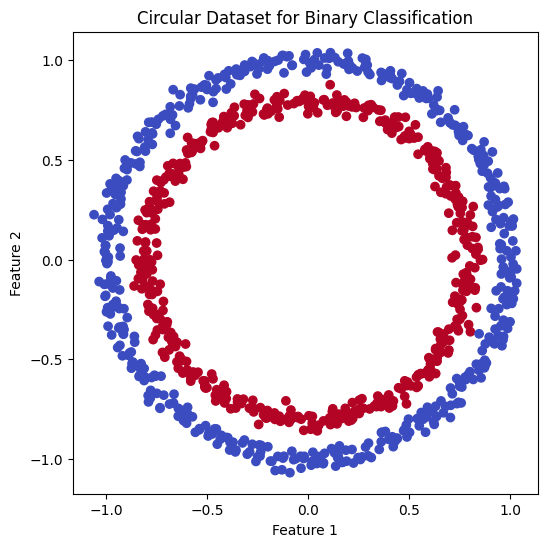

In [2]:
# 📊 To-Do: Generate and visualize a circular dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

samples = 1000
X, y = make_circles(samples, noise=0.03, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm)
plt.title("Circular Dataset for Binary Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [3]:
# ⚙️ To-Do: Build a simple neural network model

model_basic = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_basic.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_basic = model_basic.fit(X, y, epochs=50, verbose=0)
print("✅ Basic model trained.")


✅ Basic model trained.


In [4]:
# 🚀 To-Do: Improve model with more layers, neurons & optimizer

model_improved = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_improved.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_improved = model_improved.fit(X, y, epochs=100, verbose=0)
print("✅ Improved model trained.")


✅ Improved model trained.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


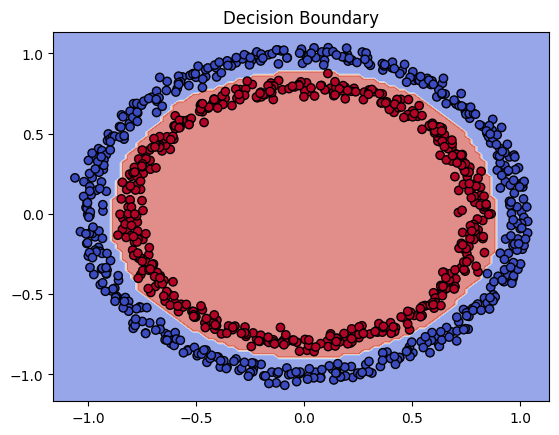

In [5]:
# 🗺️ To-Do: Define a reusable plot_decision_boundary function

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min() - 0.1, X[:,0].max() + 0.1
    y_min, y_max = X[:,1].min() - 0.1, X[:,1].max() + 0.1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    preds = (preds > 0.5).astype(int)
    plt.contourf(xx, yy, preds.reshape(xx.shape), cmap=plt.cm.coolwarm, alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(model_improved, X, y)


In [6]:
# 🔋 To-Do: Test different activation functions

for act in ["relu", "tanh", "sigmoid"]:
    print(f"\n🔹 Testing activation:", act)
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation=act),
        tf.keras.layers.Dense(8, activation=act),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.fit(X, y, epochs=50, verbose=0)
    _, acc = model.evaluate(X, y, verbose=0)
    print(f"Accuracy with {act}: {acc:.3f}")



🔹 Testing activation: relu
Accuracy with relu: 0.997

🔹 Testing activation: tanh
Accuracy with tanh: 0.887

🔹 Testing activation: sigmoid
Accuracy with sigmoid: 0.500


In [7]:
# 📚 To-Do: Split dataset and evaluate on test data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_final = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_final.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_final.fit(X_train, y_train, epochs=100, verbose=0)

test_loss, test_acc = model_final.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.3f}")


✅ Test Accuracy: 1.000


Train set decision boundary:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


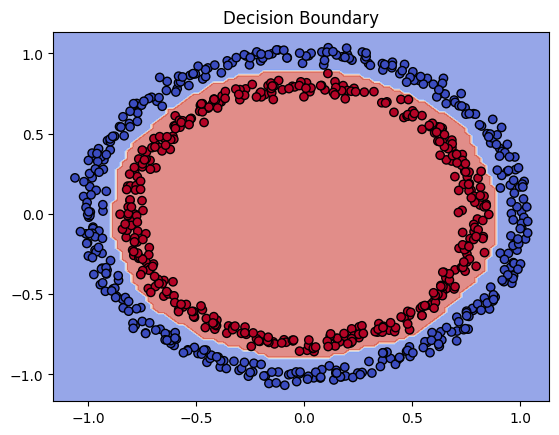

Test set decision boundary:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


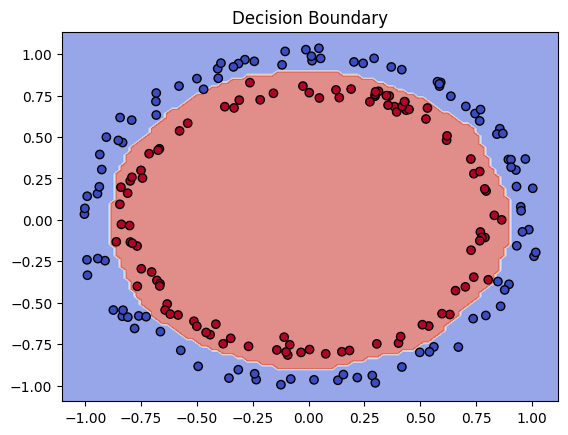

In [8]:
# 🎯 To-Do: Visualize decision boundaries for train and test sets

print("Train set decision boundary:")
plot_decision_boundary(model_final, X_train, y_train)

print("Test set decision boundary:")
plot_decision_boundary(model_final, X_test, y_test)


Summary:
- Binary classification separates data into two classes.
- Neural networks can learn complex boundaries, especially with ReLU layers.
- Adam optimizer converges faster than SGD.
- Visualizing decision boundaries helps diagnose underfitting or overfitting.
- Tuning activations, layer sizes, and epochs drastically changes performance.